In [15]:
pip install ipywidgets matplotlib pandas

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
mpl.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

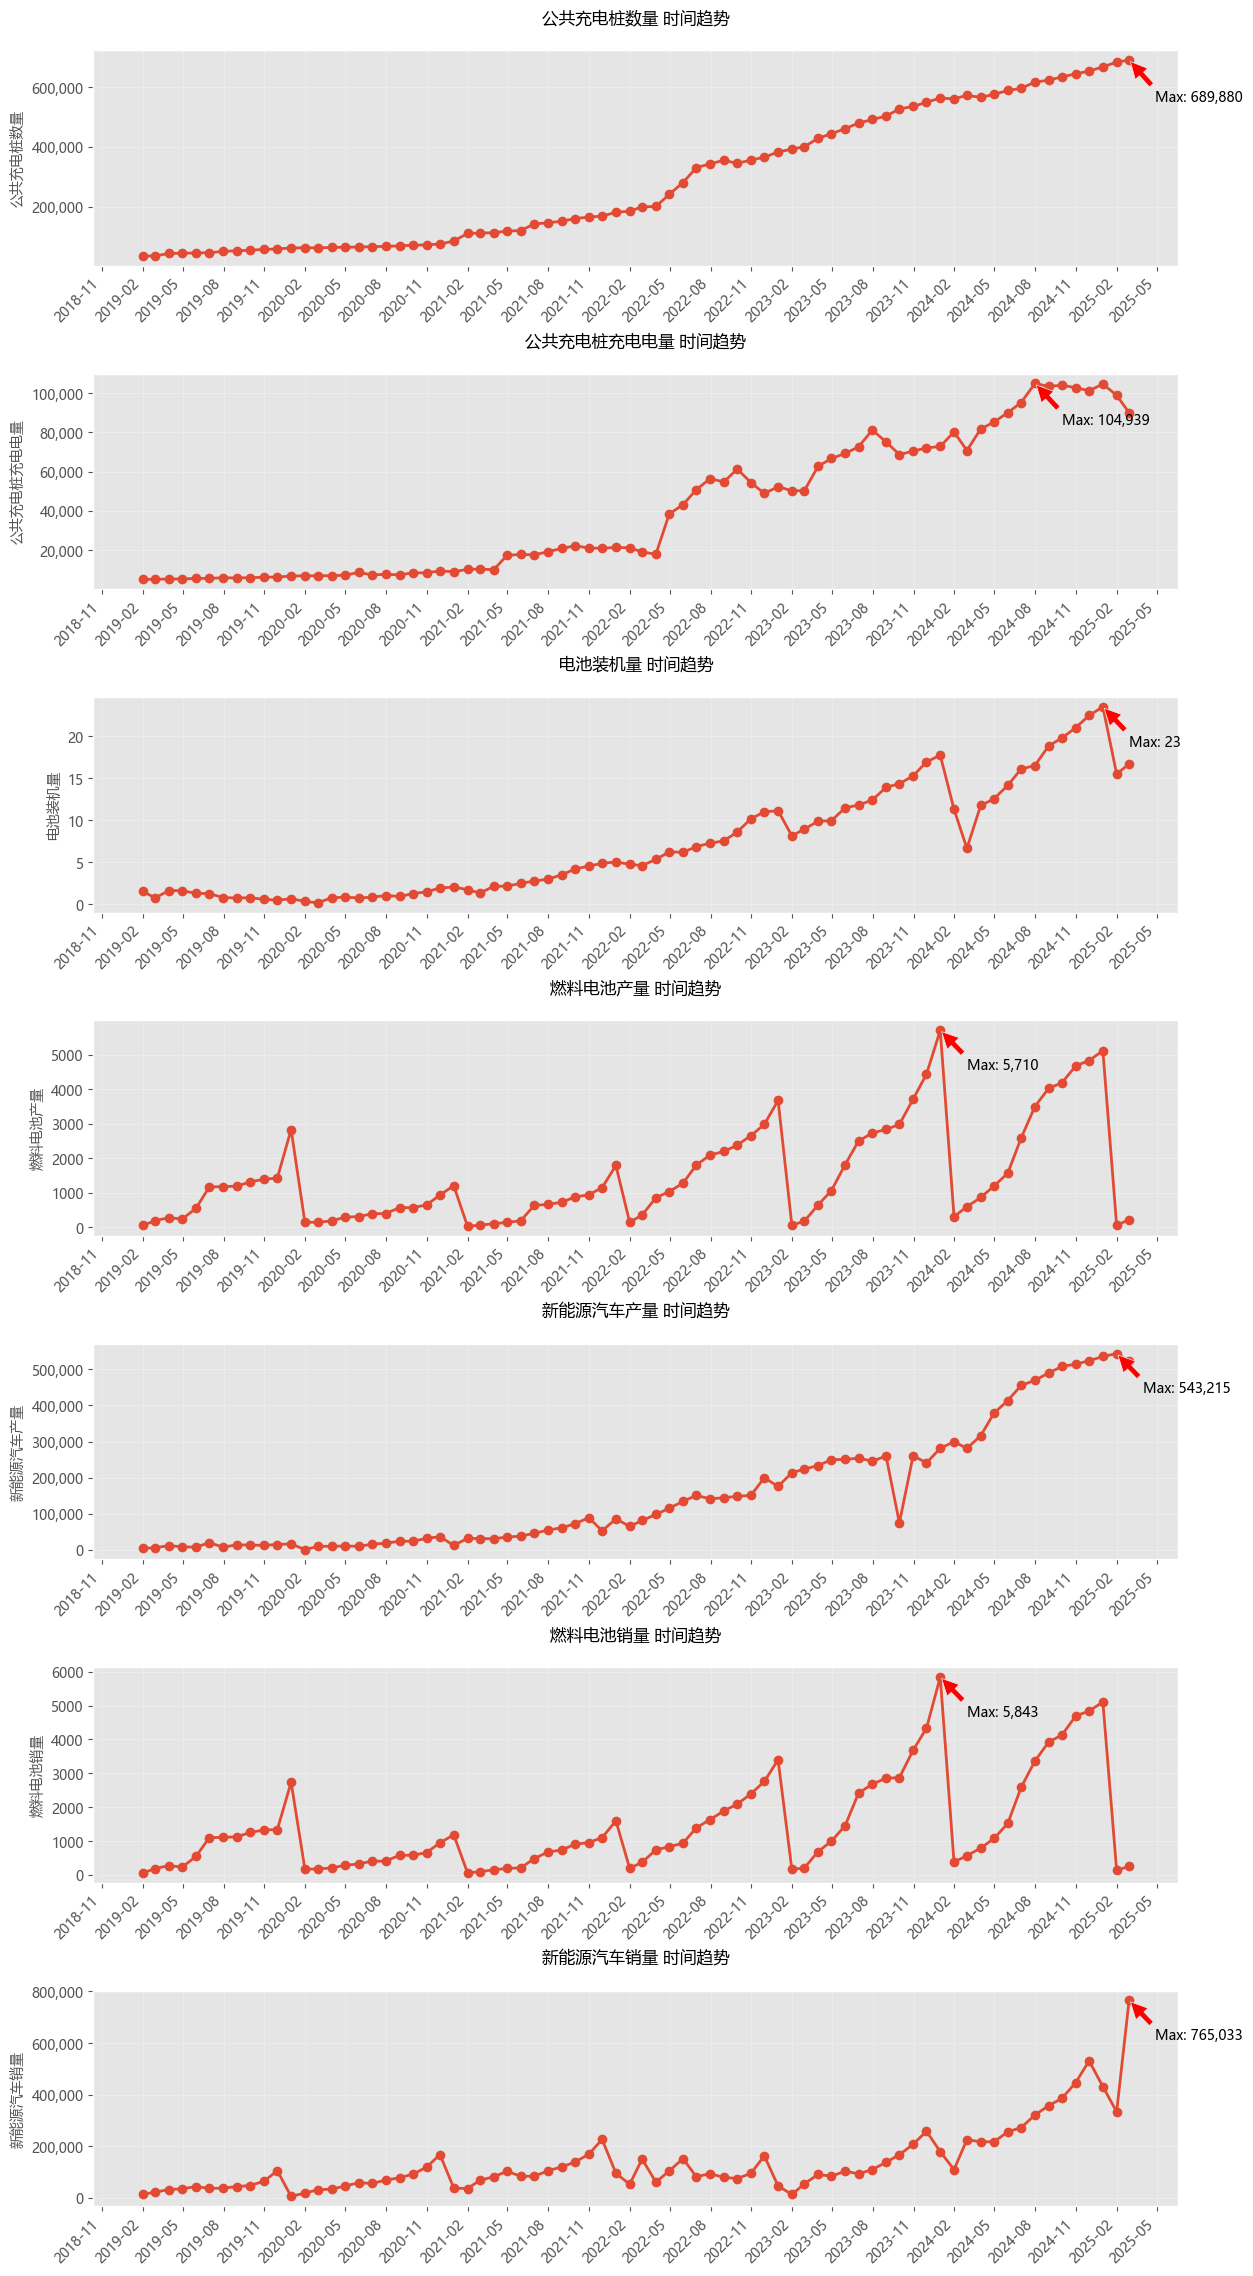

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 读取数据
df = pd.read_excel("已处理数据.xls", parse_dates=["结束日期"])
plt.style.use('ggplot')

variables = ['公共充电桩数量', '公共充电桩充电电量', '电池装机量', 
            '燃料电池产量', '新能源汽车产量', '燃料电池销量', '新能源汽车销量']

fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 28))
fig.subplots_adjust(hspace=0.5) 

for i, (var, ax) in enumerate(zip(variables, axes)):
    # 绘制折线图
    ax.plot(df["结束日期"], df[var], marker='o', linewidth=2, markersize=6)
    
    # 设置日期格式
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月显示一个标签
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # 设置坐标轴标签和标题
    ax.set_title(f"{var} 时间趋势", fontsize=12, pad=20)

    ax.set_ylabel(var, fontsize=10)
    ax.grid(True, alpha=0.3)
    
    if df[var].max() > 10000:  # 对较大数值使用千分位格式化
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # 标记特殊点（最大值）
    max_val = df[var].max()
    max_date = df.loc[df[var] == max_val, "结束日期"].values[0]
    ax.annotate(f'Max: {max_val:,.0f}', 
                xy=(max_date, max_val),
                xytext=(max_date + pd.DateOffset(months=2), max_val*0.8),
                arrowprops=dict(facecolor='red', shrink=0.05))

plt.savefig("industry_trends.png", dpi=300, bbox_inches='tight')
plt.show()